# EDA e Baseline — Previsão de Churn (Telco)

**Autor:** Alessandro Stefani  
**Data:** 2026-06-21  
**Disciplina:** Tech Challenge — Fase 01 (Produtização de Modelos)  
**Etapa:** 1 — Entendimento e Preparação  
**Descrição:** Análise exploratória do dataset Telco Customer Churn e construção de baselines (DummyClassifier e Regressão Logística), com rastreamento no MLflow.

**Dataset:** TelcoCustomerChurn.csv  
**Disponivel em:** https://www.kaggle.com/datasets/rhonarosecortez/telco-customer-churn/data

## 1. Setup e imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
#from sklearn.compose import ColumnTransformer
#from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import OneHotEncoder
#from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay



import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score


dataset_path = "../data/raw/TelcoCustomerChurn.csv"

SEED = 42

## 2. Carregamento dos dados

Dataset bruto em `data/raw/telco.csv`.

In [2]:
# Carregar dados
df = pd.read_csv(dataset_path)

print(f"Shape dos dados: {df.shape}")
print("\nPrimeiras linhas do dataset:")
df.head(10)

Shape dos dados: (7043, 50)

Primeiras linhas do dataset:


,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
5,4412-YLTKF,Female,72,No,Yes,No,Yes,1,United States,California,...,10,89.91,2235.41,1,Churned,Yes,95,4638,Competitor,Competitor had better devices
6,0390-DCFDQ,Female,76,No,Yes,Yes,Yes,2,United States,California,...,0,15.28,85.73,2,Churned,Yes,76,3964,Other,Don't know
7,3445-HXXGF,Male,66,No,Yes,Yes,No,0,United States,California,...,0,0.00,2610.25,1,Churned,Yes,91,5444,Dissatisfaction,Service dissatisfaction
8,2656-FMOKZ,Female,70,No,Yes,No,Yes,2,United States,California,...,0,661.05,1806.75,2,Churned,Yes,91,5717,Dissatisfaction,Limited range of services
9,2070-FNEXE,Female,77,No,Yes,No,Yes,2,United States,California,...,0,188.65,681.20,2,Churned,Yes,81,4419,Price,Lack of affordable download/upload speed


## 3. Análise Exploratória (EDA)

### 3.1 Visão geral e volume

Dimensões, primeiras linhas, tipos de cada coluna.

In [3]:
# Visão geral do dataset

print("Formato:")
print(f"Linhas  {df.shape[0]:,}")
print(f"Colunas {df.shape[1]:,}")

print("\n" + "Tipos de colunas:")
print(df.dtypes.value_counts())


Formato:
Linhas  7,043
Colunas 50

Tipos de colunas:
object     31
int64      11
float64     8
Name: count, dtype: int64


### 3.2 Qualidade dos dados

Valores ausentes, duplicados, tipos inconsistentes, cardinalidade das categóricas.

In [4]:
# Verificação de nulos

nulls = (
    pd.DataFrame({
        "coluna": df.columns,
        "nulos": df.isna().sum().values,
        "pct_nulos": (df.isna().mean() * 100).round(2).values
    })
    .sort_values("pct_nulos", ascending=False)
)

#print("\n" + "=" * 80)
print("Colunas com nulos")
#print("=" * 80)

display(nulls.query("nulos > 0"))


Colunas com nulos


,coluna,nulos,pct_nulos
49,ChurnReason,5174,73.46
48,ChurnCategory,5174,73.46
19,Offer,3877,55.05
24,InternetType,1526,21.67


**ChurnReason:** Não será utilizada, pois contém informação sobre a variável resposta (data leakage)  
**ChurnCategory:**  Não será utilizada, pois contém informação sobre a variável resposta (data leakage)  
**Offer:** De acordo com a descrição do dataset, o cliente não tem campanha ativa, então o nulo carrega informação. Popular com "No offer"  
**InternetType:** Os valores nulos são de clientes que não possuem serviço de internet (confirmado com InternetService). Avaliar qual das duas tem mais valor para o modelo  


In [5]:
# Verificação de cardinalidade

cardinalidade = (
    pd.DataFrame({
        "coluna": df.columns,
        "tipo": df.dtypes.astype(str),
        "valores_unicos": df.nunique(dropna=False).values,
        "pct_unicos": (
            df.nunique(dropna=False)
            / len(df)
            * 100
        ).round(2).values
    })
    .sort_values("valores_unicos")
)

print("Cardinalidade" + "\n")

display(cardinalidade)


Cardinalidade



,coluna,tipo,valores_unicos,pct_unicos
State,State,object,1,0.01
Quarter,Quarter,object,1,0.01
Country,Country,object,1,0.01
Gender,Gender,object,2,0.03
Dependents,Dependents,object,2,0.03
Under30,Under30,object,2,0.03
Married,Married,object,2,0.03
SeniorCitizen,SeniorCitizen,object,2,0.03
OnlineBackup,OnlineBackup,object,2,0.03
OnlineSecurity,OnlineSecurity,object,2,0.03


In [6]:
# Análise estatística das variáveis numéricas

print("Descrição das variáveis numéricas" + "\n")

display(df.describe().round(10).T)


Descrição das variáveis numéricas



,count,mean,std,min,25%,50%,75%,max
Age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
NumberofDependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
ZipCode,7043.0,93486.070567,1856.767505,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
Latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
Population,7043.0,22139.603294,21152.392837,11.000000,2344.000000,17554.000000,36125.000000,105285.000000
Number_of_Referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
TenureinMonths,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
AvgMonthlyLongDistanceCharges,7043.0,22.958954,15.448113,0.000000,9.210000,22.890000,36.395000,49.990000
AvgMonthlyGBDownload,7043.0,20.515405,20.418940,0.000000,3.000000,17.000000,27.000000,85.000000


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)

Index(['Age', 'NumberofDependents', 'ZipCode', 'Latitude', 'Longitude',
       'Population', 'Number_of_Referrals', 'TenureinMonths',
       'AvgMonthlyLongDistanceCharges', 'AvgMonthlyGBDownload',
       'MonthlyCharge', 'TotalCharges', 'TotalRefunds',
       'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue',
       'SatisfactionScore', 'ChurnScore', 'CLTV'],
      dtype='object')


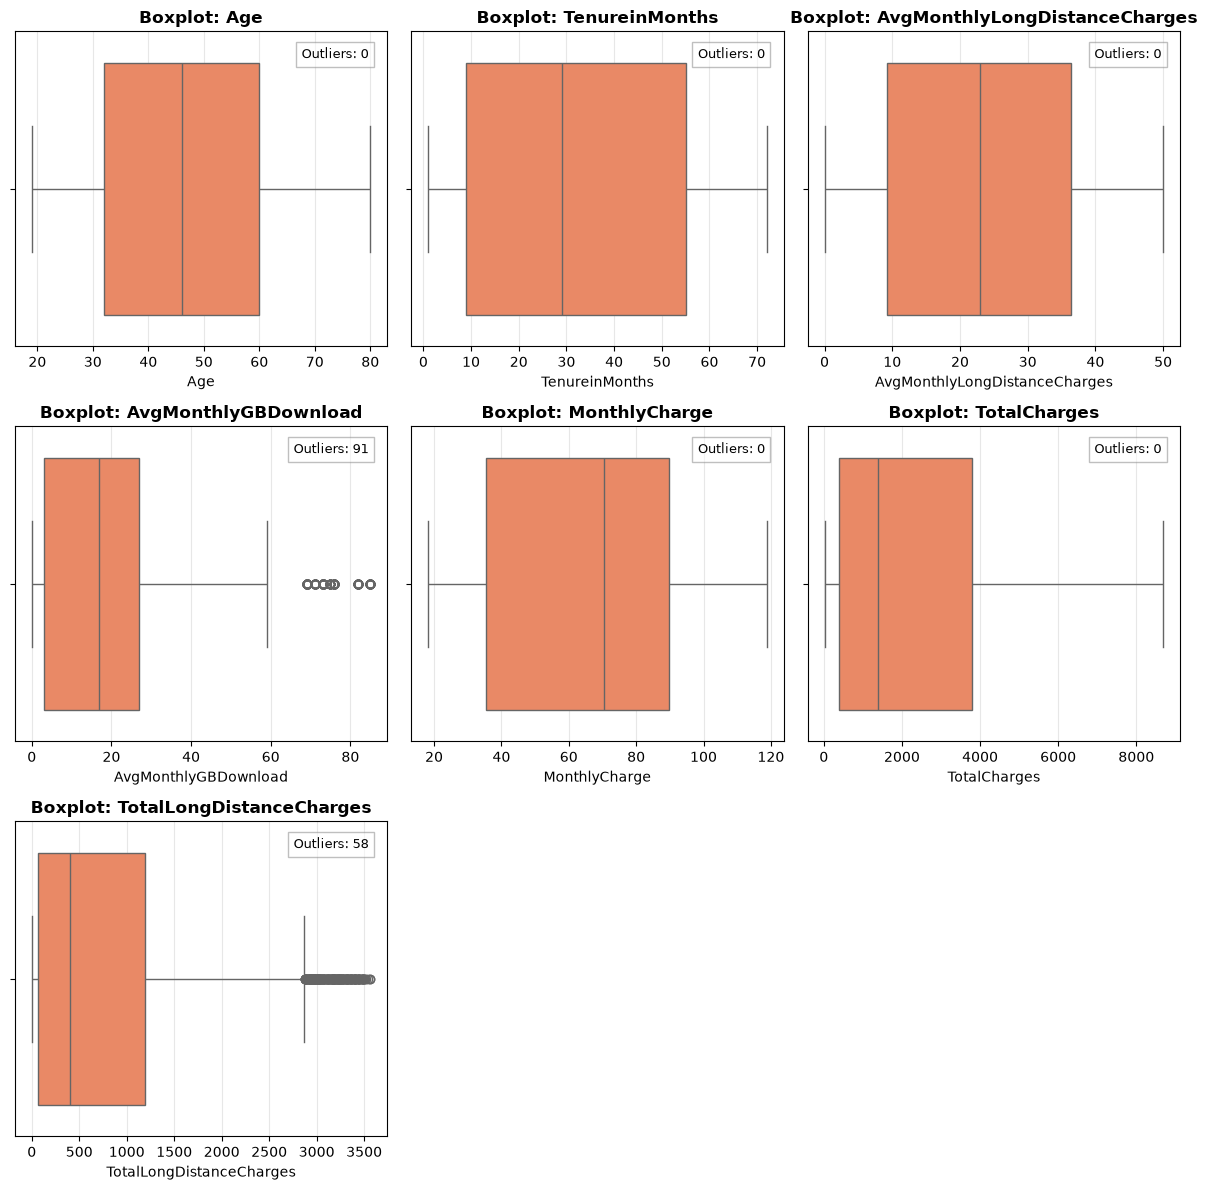

In [8]:
# Colunas numéricas (excluindo geográficas e leakage confirmado/suspeito)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['ZipCode', 'Latitude', 'Longitude', 'Population'])
numeric_cols = numeric_cols.drop(['TotalRevenue', 'ChurnScore', 'CLTV', 'SatisfactionScore'])
numeric_cols = numeric_cols.drop(['NumberofDependents', 'Number_of_Referrals', 'TotalRefunds', 'TotalExtraDataCharges'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


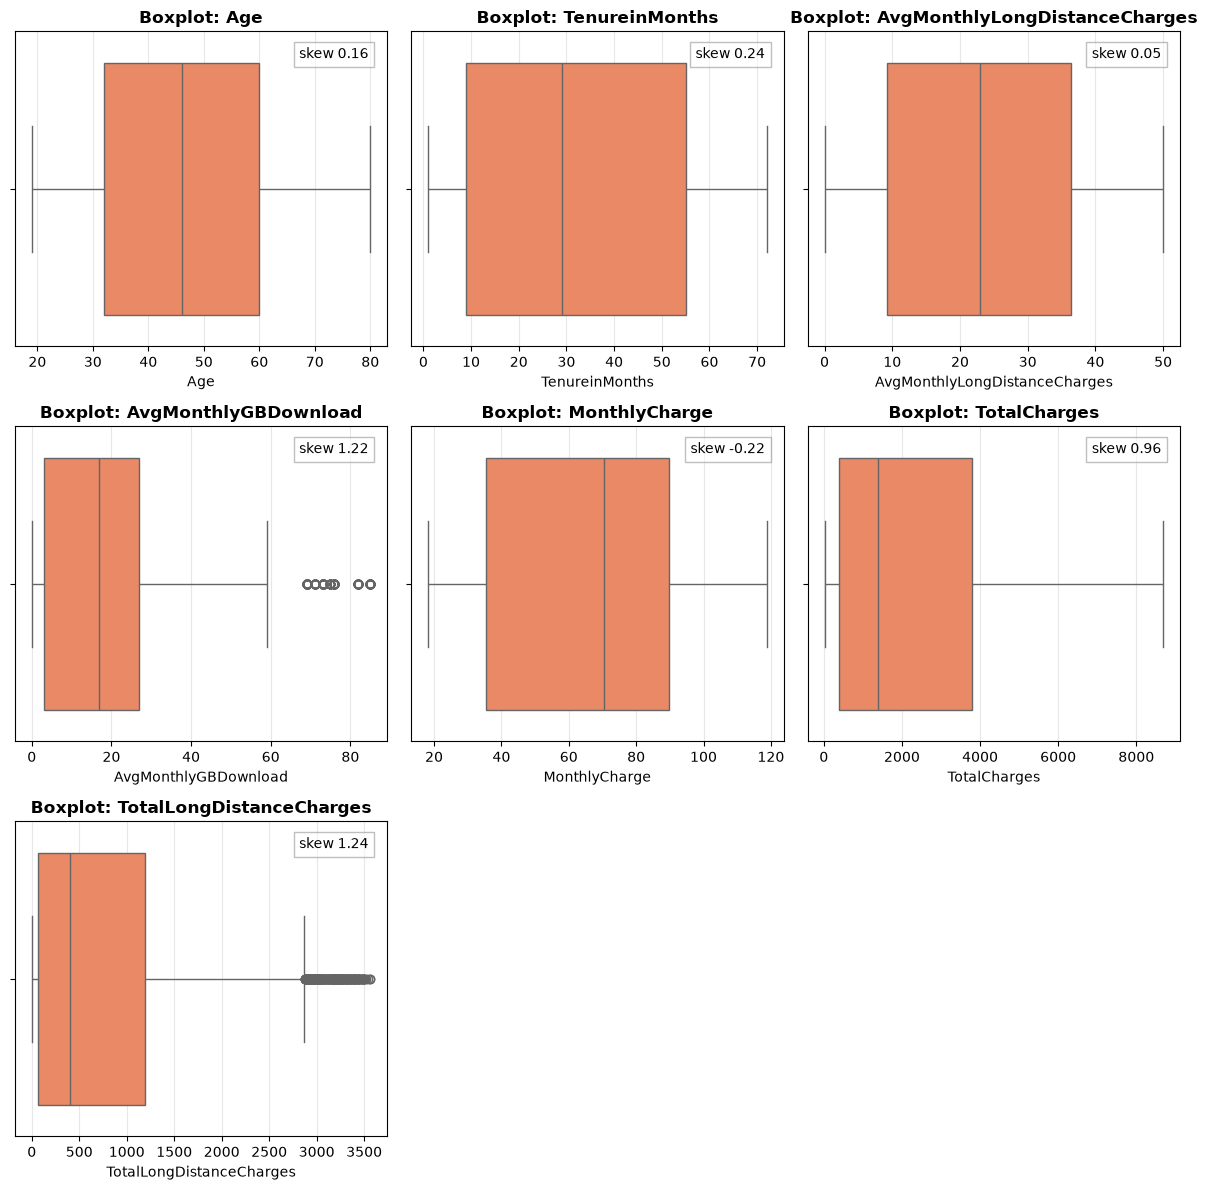

In [9]:
# Colunas numéricas (excluindo geográficas e leakage confirmado/suspeito)
n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f"skew {df[col].skew():.2f}",
                   transform=axes[idx].transAxes, ha="right", va="top",
                   bbox=dict(facecolor="white", alpha=0.5, edgecolor="gray"))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [10]:
# Análise de relacionamento entre ZipCode e Latitude/Longitude

(df.groupby(["Latitude", "Longitude"])["ZipCode"].nunique().describe())

count    1626.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: ZipCode, dtype: float64

In [11]:
# Verificação de TotalRevenue ser calculada a partir de outras

revenue_calculada = (
    df["TotalCharges"]
    + df["TotalLongDistanceCharges"]
    + df["TotalExtraDataCharges"]
    - df["TotalRefunds"]
)

diferenca = df["TotalRevenue"] - revenue_calculada

display(diferenca.describe().round(10))

count    7043.0
mean       -0.0
std         0.0
min        -0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

In [12]:
# Análise de SatisfactionScore ser possível data leakage

pd.crosstab(
    df["TotalRefunds"],
    df["ChurnLabel"],
    margins=True
)


#numeric_cols = numeric_cols.drop(['TotalRevenue', 'ChurnScore', 'CLTV', 'SatisfactionScore'])
#numeric_cols = numeric_cols.drop(['NumberofDependents', 'Number_of_Referrals', 'TotalRefunds', 'TotalExtraDataCharges'])


ChurnLabel,No,Yes,All
TotalRefunds,,,
0.0,4756,1762,6518
1.01,1,0,1
1.09,1,0,1
1.27,0,1,1
1.31,2,0,2
...,...,...,...
49.53,1,0,1
49.57,0,2,2
49.76,1,0,1


In [13]:
# Análise das variáveis categóricas

print("Descrição das variáveis categóricas" + "\n")

display(df.describe(include="object").T)


Descrição das variáveis categóricas



,count,unique,top,freq
CustomerID,7043,7043,8779-QRDMV,1
Gender,7043,2,Male,3555
Under30,7043,2,No,5642
SeniorCitizen,7043,2,No,5901
Married,7043,2,No,3641
Dependents,7043,2,No,5416
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1106,Los Angeles,293
Quarter,7043,1,Q3,7043


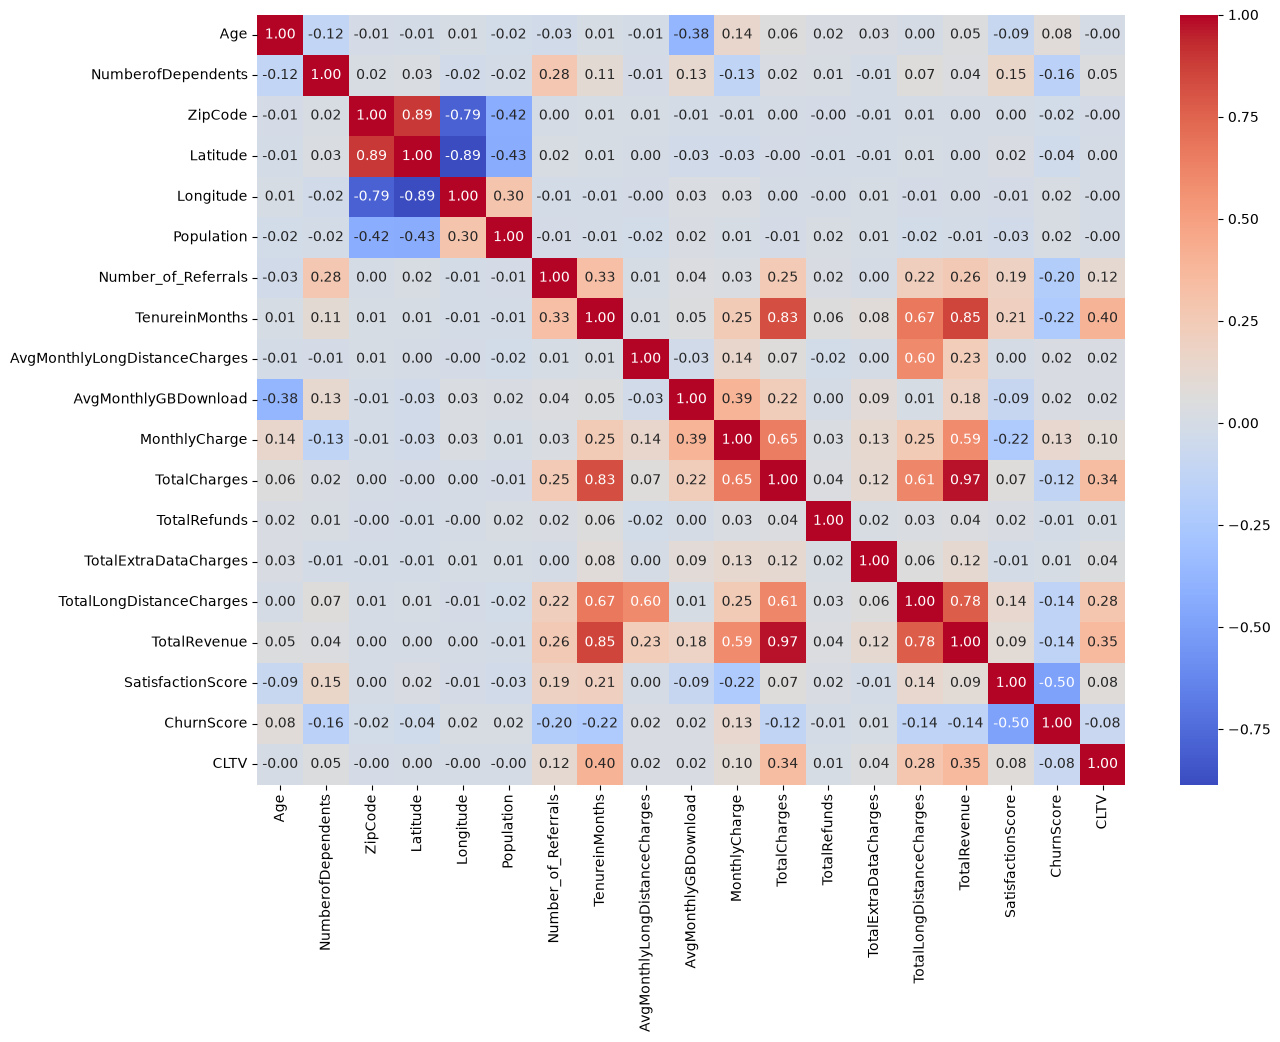

In [14]:
# Análise de correlação das variáveis

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.show()

### 3.3 Distribuições e relação com o alvo (Churn)

Balanceamento da classe alvo; distribuição das numéricas e categóricas; relação com o churn.

ChurnLabel
No     5174
Yes    1869
Name: count, dtype: int64


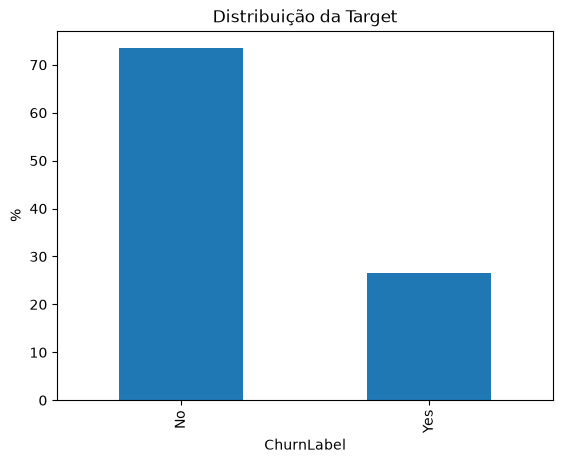

Classe majoritária: No (73.46%)
Classe minoritária: Yes (26.54%)

Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado!


In [15]:
print(df["ChurnLabel"].value_counts())


(df["ChurnLabel"]
    .value_counts(normalize=True)
    .mul(100)
    .plot(kind="bar")
)

plt.ylabel("%")
plt.title("Distribuição da Target")
plt.show()


dist = (
    df["ChurnLabel"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(f"Classe majoritária: {dist.idxmax()} ({dist.max()}%)")
print(f"Classe minoritária: {dist.idxmin()} ({dist.min()}%)")


dist = df["ChurnLabel"].value_counts()

maior = dist.max()
menor = dist.min()

ratio = menor / maior
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado!")
else:
    print("✓ Dataset razoavelmente balanceado.")

In [16]:
# Análise de correlação de variáveis numéricas com target
# Excluindo variáveis geográficas e com leakage possível/confirmado

cols_fora = ['ZipCode', 'Latitude', 'Longitude', 'Population', 'CLTV', 'TotalRevenue', 'ChurnScore']

churn_num = (
    df["ChurnLabel"]
      .map({
          "No": 0,
          "Yes": 1
      })
)

corr_target = (
    df.select_dtypes(include="number")
      .drop(columns=cols_fora)
      .corrwith(churn_num)
      .sort_values()
)

display(
    corr_target.to_frame(
        "Correlacao_Com_Churn"
    )
)

,Correlacao_Com_Churn
SatisfactionScore,-0.754649
TenureinMonths,-0.352861
Number_of_Referrals,-0.286540
TotalLongDistanceCharges,-0.223756
NumberofDependents,-0.218780
TotalCharges,-0.198546
TotalRefunds,-0.033709
TotalExtraDataCharges,0.007139
AvgMonthlyLongDistanceCharges,0.008120
AvgMonthlyGBDownload,0.048868


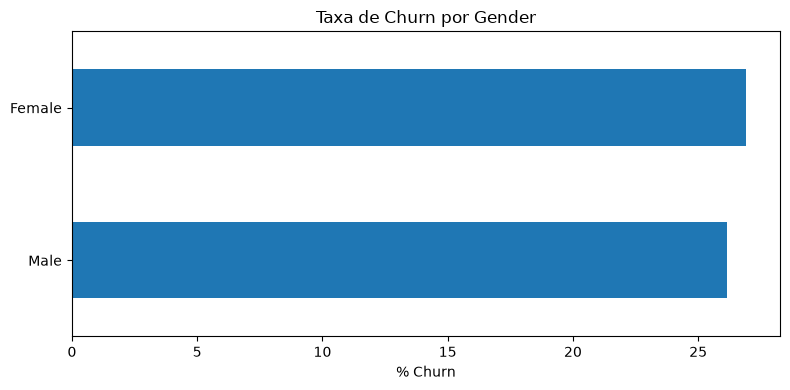

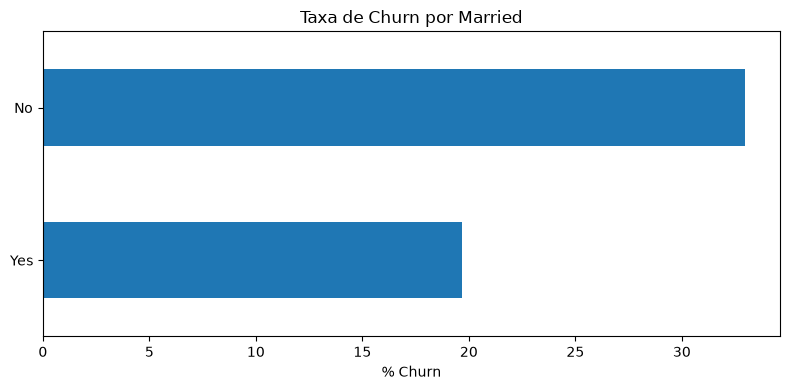

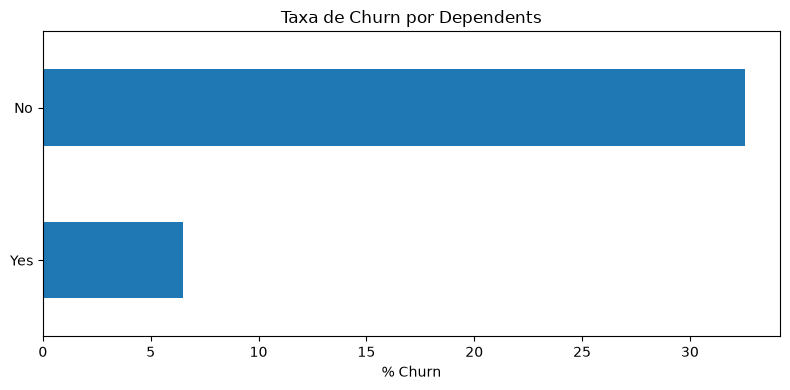

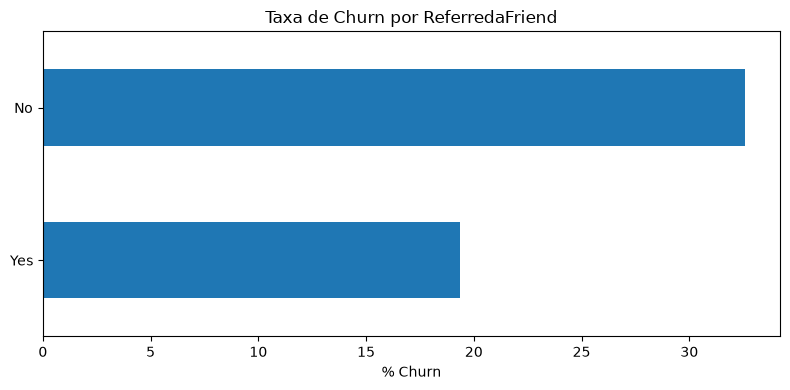

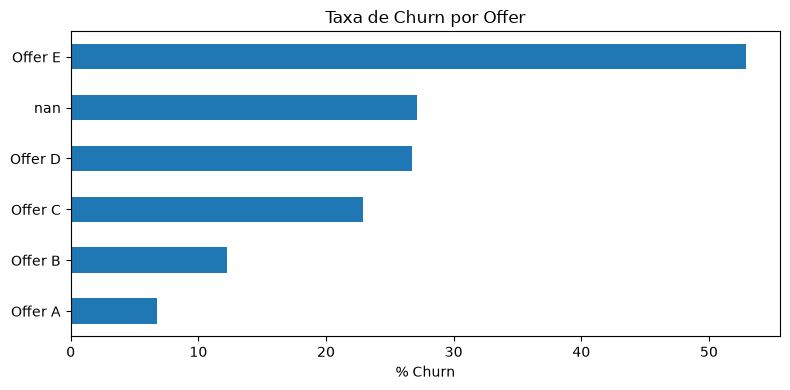

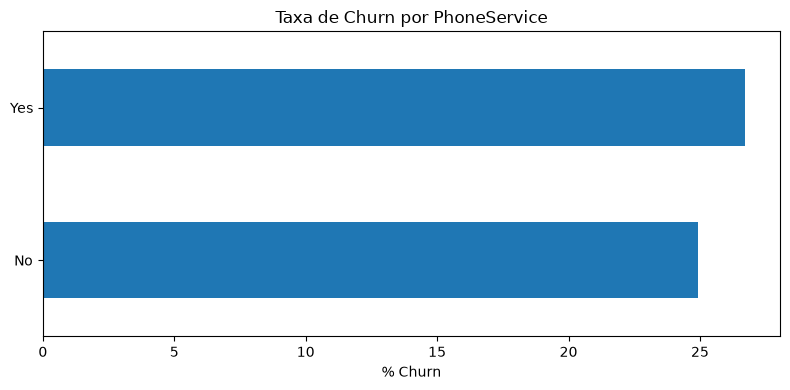

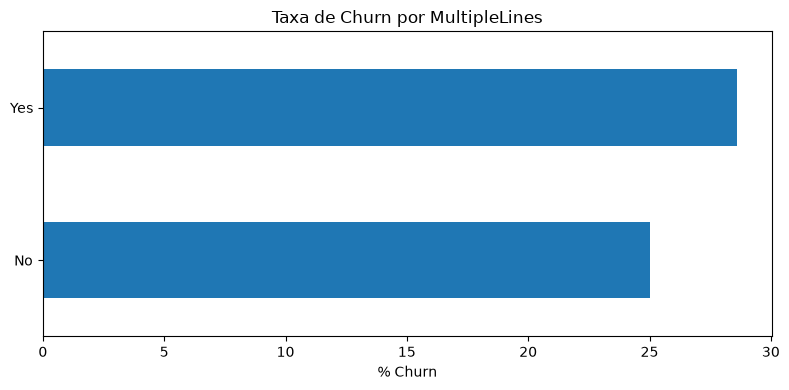

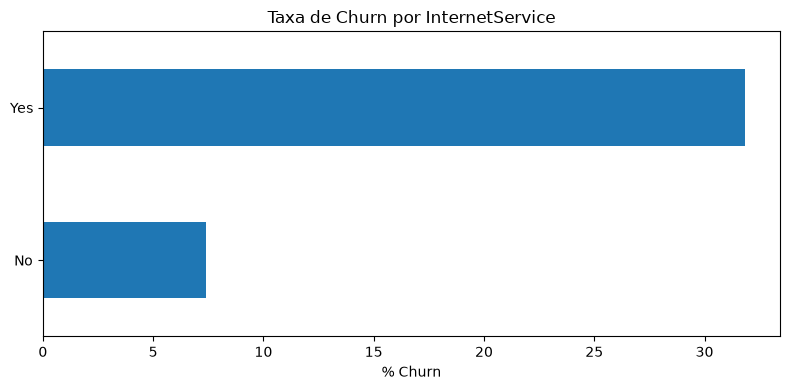

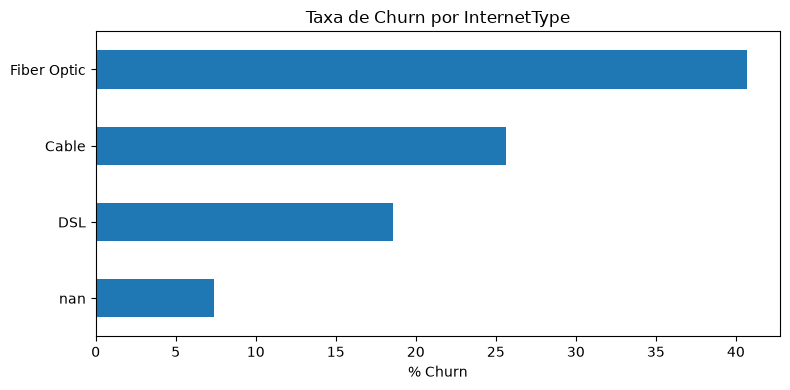

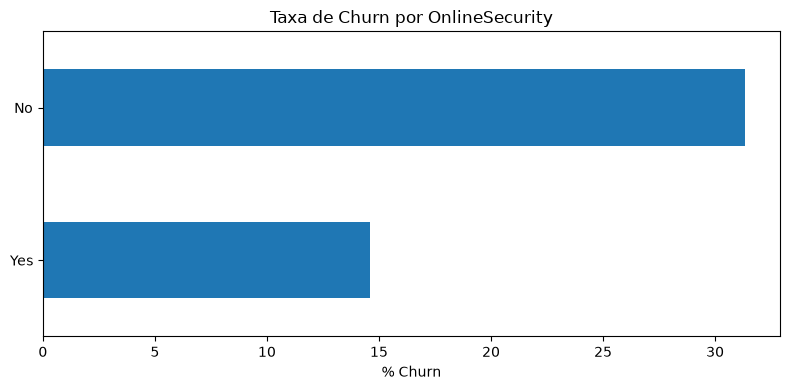

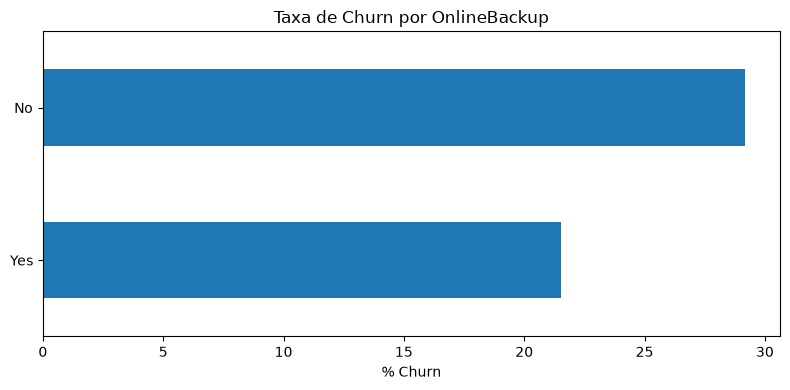

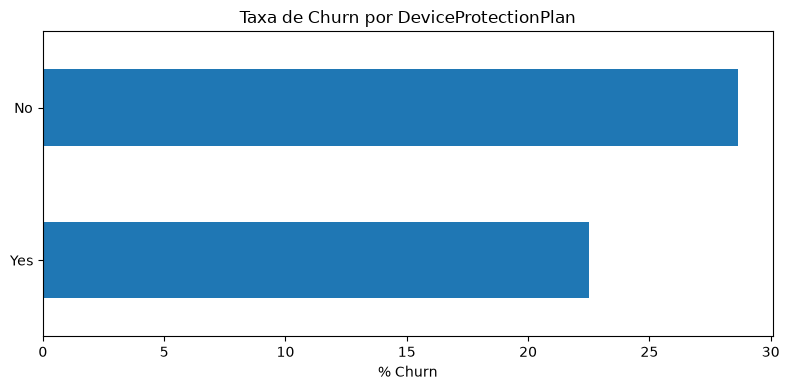

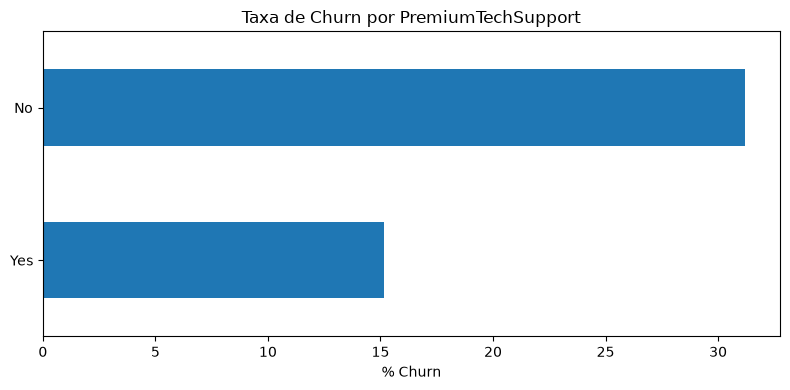

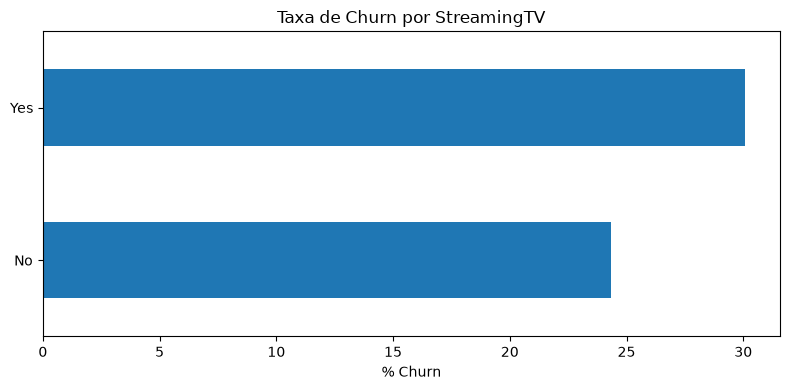

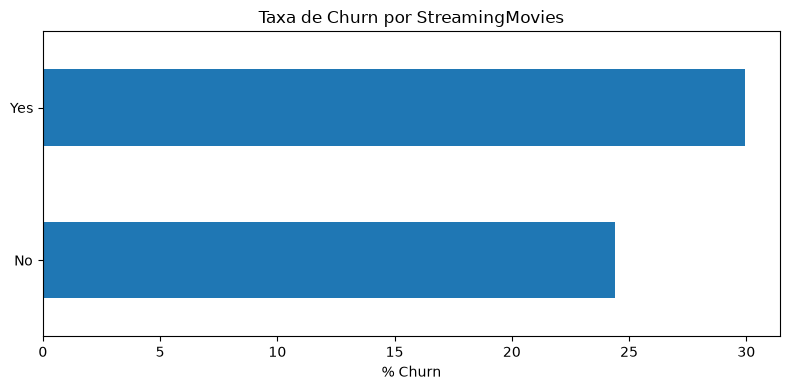

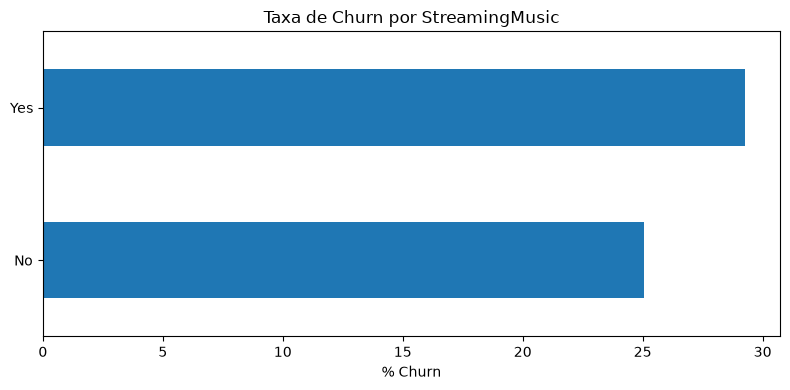

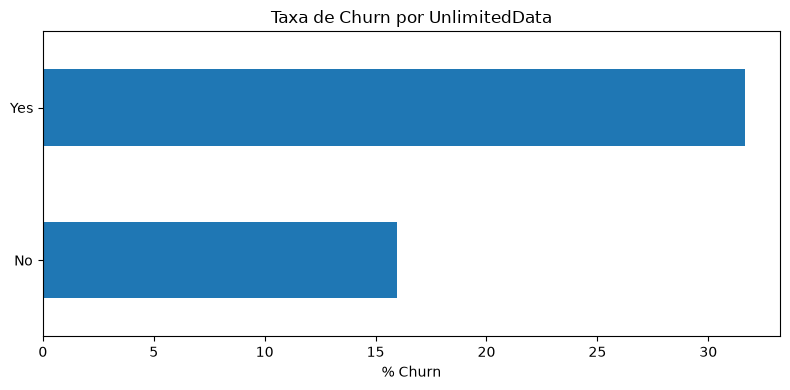

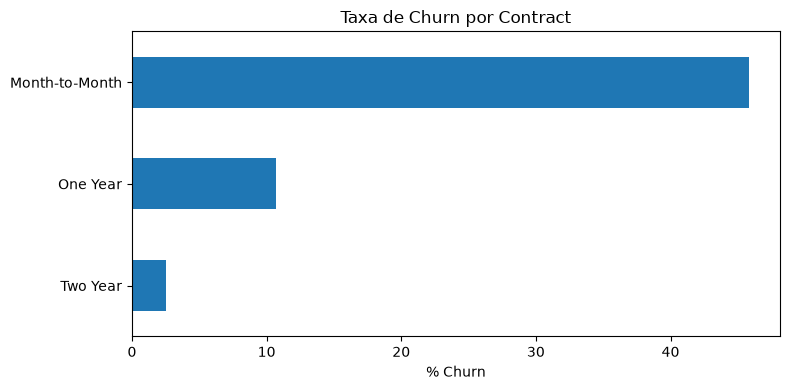

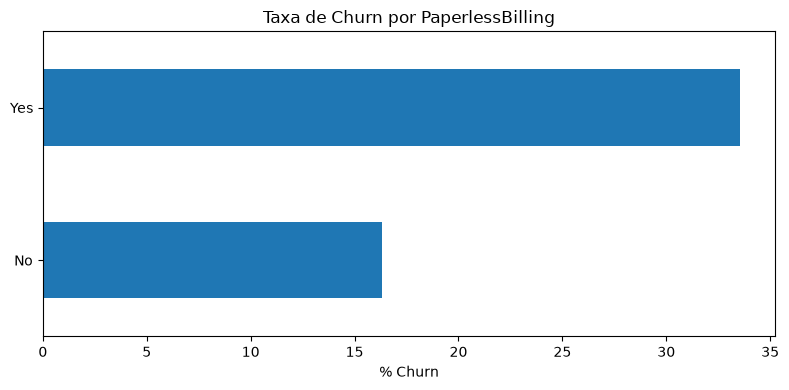

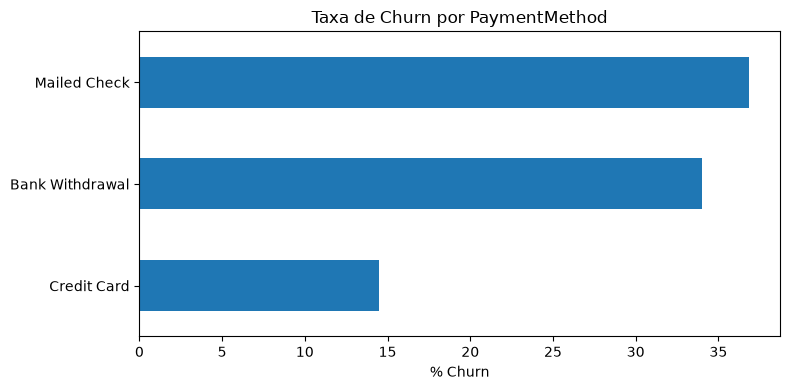

In [17]:
# Análise gráfica de relacionamento entre variáveis categóricas e target
# Excluindo variáveis de identificação, geográficas, redundantes e com leakage possível/confirmado

TARGET = "ChurnLabel"

cat_cols = df.select_dtypes(include="object").columns
cat_cols = cat_cols.drop(['CustomerID', 'ChurnReason', 'ChurnCategory', 'CustomerStatus', 'City'])
cat_cols = cat_cols.drop(['Country', 'State', 'Quarter'])
cat_cols = cat_cols.drop(['Under30', 'SeniorCitizen']).tolist()


cat_cols = [col for col in cat_cols if col != TARGET]

for col in cat_cols:
    churn_rate = (
        pd.crosstab(
            df[col],
            df[TARGET],
            dropna=False,
            normalize="index"
        )
        .mul(100)
        .round(2)
    )

    if "Yes" not in churn_rate.columns:
        continue

    churn_rate["Yes"].sort_values().plot(
        kind="barh",
        figsize=(8, 4)
    )

    plt.title(f"Taxa de Churn por {col}")
    plt.xlabel("% Churn")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

In [18]:
# Análise numérica de relacionamento entre variáveis categóricas e target
# Excluindo variáveis de identificação, geográficas, redundantes e com leakage possível/confirmado

TARGET = "ChurnLabel"

cat_cols = df.select_dtypes(include="object").columns
cat_cols = cat_cols.drop(['CustomerID', 'ChurnReason', 'ChurnCategory', 'CustomerStatus', 'City'])
cat_cols = cat_cols.drop(['Country', 'State', 'Quarter'])
cat_cols = cat_cols.drop(['Under30', 'SeniorCitizen']).tolist()

cat_cols = [col for col in cat_cols if col != TARGET]

for col in cat_cols:

    print("\n" + "=" * 80)
    print(col)
    print("=" * 80)

    display(
        pd.crosstab(
            df[col],
            df[TARGET],
            dropna=False,
            normalize="index"
        )
        .mul(100)
        .round(2)
    )


Gender


ChurnLabel,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16



Married


ChurnLabel,No,Yes
Married,,
No,67.04,32.96
Yes,80.34,19.66



Dependents


...

ChurnLabel,No,Yes
Contract,,
Month-to-Month,54.16,45.84
One Year,89.29,10.71
Two Year,97.45,2.55



PaperlessBilling


ChurnLabel,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57



PaymentMethod


ChurnLabel,No,Yes
PaymentMethod,,
Bank Withdrawal,66.00,34.00
Credit Card,85.52,14.48
Mailed Check,63.12,36.88


### 3.4 Data readiness

Síntese da EDA: o dado está pronto para modelar? Quais tratamentos serão necessários?

### 3.4 Data readiness

**Veredito:** dataset pronto para modelagem — sem bloqueios de qualidade.
Os tratamentos necessários estão definidos abaixo e serão aplicados no pipeline (Seção 5), nunca no `df` cru.

#### Integridade
- 7.043 linhas × 50 colunas. Sem duplicatas (`CustomerID` 100% único).
- Sem valores numéricos impossíveis (todos `min ≥ 0`, máximos plausíveis).
- Nulos concentrados em 4 colunas, todos com tratamento definido (abaixo).

#### Alvo
- `ChurnLabel`: 26,5% de churn (1.869 / 5.174) → desbalanceamento com ratio de 0,36.
- Implica: split **estratificado**, métrica sensível a desbalanceamento (Seção 4) e avaliar `class_weight="balanced"`.

#### Features removidas (detalhe em docs/Notas_para_model_card.md)
- **Identificador:** CustomerID
- **Leakage:** CustomerStatus, ChurnScore, ChurnCategory, ChurnReason
- **Precaução:** CLTV
- **Redundância:** ZipCode, SeniorCitizen, Under30, TotalRevenue, InternetService
- **Constantes (variância zero):** Country, State, Quarter
- **Alta cardinalidade / geo redundante:** City

#### Decisão pendente
- `SatisfactionScore`: leakage suspeito (doc sem âncora temporal + separação 100/0%). Será testada **com e sem** no baseline; decisão final após comparar.

#### Tratamentos para o pipeline (Seção 5)
| Tratamento | Colunas |
|---|---|
| Imputar valor de negócio | Offer → "No offer"; InternetType → "No internet" |
| One-hot encoding | categóricas (binárias + Contract, PaymentMethod, Offer, InternetType) |
| StandardScaler | numéricas em geral |
| Testar log1p / RobustScaler | TotalLongDistanceCharges, AvgMonthlyGBDownload (cauda direita, skew ~1,2) |
| Remoção de linhas | nenhuma (outliers verificados como legítimos) |
| Mapear alvo | ChurnLabel Yes/No → 1/0 |
  
> Todo o pré-processamento vai **dentro do Pipeline**, ajustado só no treino, para não vazar a distribuição do teste.

#### Sinais observados (insumo para a modelagem)
- `TenureinMonths` é o preditor numérico mais forte (correlação negativa de -0.352861, indicando que cliente tem churn maior).
- `Married e Dependents` possuem elevada capacidade preditora, indicando que ter mais pessoas usando tende a reduzir o churn.
- `ReferredaFriend` é bom preditor, significando que indicações indicam satisfação e possível permanência
- `Offer` discrimina: "No offer" ~27% vs Offer E 53%.
- `Contract, PaperlessBilling e PaymentMethod` tem elevado poder discriminatório.
- `PhoneService e MultipleLines` tem baixo poder discriminatório, indicando que serviço de telefonia não é diferencial.


## 4. Definição de métricas

#### **Métricas técnicas**
`Acurácia ((TP+TN)/total)` — Taxa de acerto geral. Ruim sob desbalanceamento.  
`Precisão (TP/(TP+FP))` — A taxa de acerto das previsões positivas.  
`Recall (TP/(TP+FN))` — A taxa de acerto dos casos realmente positivos.  
`F1` — Média harmônica de P e R.  
`ROC-AUC` — Área sob a curva TPR × FPR (FPR = FP/(FP+TN)).  
`PR-AUC (principal)` — Área sob a curva Precisão × Recall.

In [19]:
# Definição do experimento e métricas de performance

mlflow.set_experiment("customer_churn_prediction")

resultados = {}
predicoes  = {}   # nome -> (y_test, y_proba_test) para as curvas ROC e PR

def logar_metricas(y_train, y_pred_train, y_proba_train, y_test, y_pred_test, y_proba_test):
    """Calcula e loga o MESMO conjunto de métricas para qualquer modelo,
    garantindo que todos os runs do MLflow sejam comparáveis."""
    m = {
        "train_accuracy": accuracy_score(y_train, y_pred_train),
        "test_accuracy":  accuracy_score(y_test,  y_pred_test),
        "test_f1_score":  f1_score(y_test, y_pred_test),
        "test_precision": precision_score(y_test, y_pred_test),
        "test_recall":    recall_score(y_test, y_pred_test),
        "test_roc_auc":   roc_auc_score(y_test, y_proba_test),
        "test_pr_auc":    average_precision_score(y_test, y_proba_test),
        "train_pr_auc":    average_precision_score(y_train, y_proba_train),
    }
    m["overfitting"] = m["train_accuracy"] - m["test_accuracy"]
    m["dif_pr_auc"] = m["train_pr_auc"] - m["test_pr_auc"]
    for nome, valor in m.items():
        mlflow.log_metric(nome, valor)
    return m


2026/06/28 16:36:09 INFO mlflow.tracking.fluent: Experiment with name 'customer_churn_prediction' does not exist. Creating a new experiment.


#### **Métricas de negócio**
`custo = c_FN · (falsos negativos) + c_FP · (falsos positivos)`  
  
**Onde:**  
**c_FN** é o custo da perda de clientes que o modelo previu permanência incorretamente  
**c_FP** é o custo das campanhas e/ou tratamentos para clientes que o modelo previu churn incorretamente  
  

`Os pesos c_FN e c_FP serão definidos quando a estratégia de retenção for conhecida.`

## 5. Pré-processamento e split

Split estratificado treino/teste com seed fixa.

In [20]:
# Cópia do dataset original e imputação de valores

df_model = df.copy()

# Imputação de valores para Offer e InternetType
df_model["Offer"]        = df_model["Offer"].fillna("No offer")
df_model["InternetType"] = df_model["InternetType"].fillna("No internet")

# Criação de Y, com valores 0/1
y = df_model["ChurnLabel"].map({"No": 0, "Yes": 1})


In [21]:
# Identifição de grupos de colunas e cenários

COLS_DROP_BASE = [
    "ChurnLabel",                                                              # vira y
    "CustomerID",                                                              # id
    "CustomerStatus", "ChurnScore", "ChurnCategory", "ChurnReason",            # leakage
    "CLTV",                                                                    # precaução
    "ZipCode", "SeniorCitizen", "Under30", "ReferredaFriend", "Dependents",    # redundância
    "TotalRevenue", "InternetService",                                         # redundância
    "Country", "State", "Quarter",                                             # constantes
    "City",                                                                    # alta cardinalidade
    #"SatisfactionScore",                                                      # leakage suspeito → cenário "SEM"
]

SKEWED = ["TotalLongDistanceCharges", "AvgMonthlyGBDownload"]

cenarios = {
    "com_satisfaction": COLS_DROP_BASE,
    "sem_satisfaction": COLS_DROP_BASE + ["SatisfactionScore"],
    "sem_satisf_e_geo": COLS_DROP_BASE + ["SatisfactionScore", "Latitude", "Longitude"],
}


## 6. Baselines e Model Registry

Nesta seção treinamos dois baselines — DummyClassifier (piso de referência) e Regressão Logística — e registramos parâmetros, métricas e artefatos no MLflow. A comparação é feita com e sem SatisfactionScore para quantificar a suspeita de data leakage levantada na EDA. O versionamento do dataset será incorporado no próximo notebook (MLP).

**DummyClassifier** (referência trivial)

In [22]:
# Modelo com DummyClassifier, para ser usado como comparação

y_train, y_test = train_test_split(y, test_size=0.2, stratify=y, random_state=SEED)

X_ph_train = np.zeros((len(y_train), 1))   # placeholder: stratified ignora as features
X_ph_test  = np.zeros((len(y_test),  1))

with mlflow.start_run(run_name="dummy_stratified"):
    mlflow.log_param("modelo", "dummy_stratified")

    dummy = DummyClassifier(strategy="stratified", random_state=SEED)
    dummy.fit(X_ph_train, y_train)

    metr = logar_metricas(
        y_train, dummy.predict(X_ph_train), dummy.predict_proba(X_ph_train)[:, 1],
        y_test,  dummy.predict(X_ph_test), dummy.predict_proba(X_ph_test)[:, 1],
    )

    mlflow.sklearn.log_model(dummy, "model")

    resultados["dummy"] = metr
    predicoes["dummy"]  = (y_test, dummy.predict_proba(X_ph_test)[:, 1])

    print("=== DUMMY ===")
    for k, v in metr.items():
        print(f"{k:<16}{v:.4f}")
    print()


2026/06/28 16:36:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== DUMMY ===
train_accuracy  0.6207
test_accuracy   0.6217
test_f1_score   0.2903
test_precision  0.2891
test_recall     0.2914
test_roc_auc    0.5163
test_pr_auc     0.2723
train_pr_auc    0.2697
overfitting     -0.0010
dif_pr_auc      -0.0027



**Regressão Logística** (Avaliando se SatisfactionScore é data leakage)

In [23]:
# Dois cenários: Com e sem SatisfactionScore

for nome, cols_drop in cenarios.items():
    X = df_model.drop(columns=cols_drop)
    X[SKEWED] = np.log1p(X[SKEWED])
    X = pd.get_dummies(X, columns=X.select_dtypes("object").columns, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )
    
    num_cols  = [c for c in X_train.select_dtypes("number").columns]

    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols]  = scaler.transform(X_test[num_cols])


    with mlflow.start_run(run_name=f"logreg_{nome}"):
        mlflow.log_param("modelo", "logistic_regression")
        mlflow.log_param("inclui_satisfaction", "com" in nome)
        mlflow.log_param("n_features", X_train.shape[1])

        # class_weight="balanced" → alinha com RF e com o pos_weight da MLP (comparação justa)
        model = LogisticRegression(random_state=SEED, max_iter=1000, class_weight="balanced")
        model.fit(X_train, y_train)

        metr = logar_metricas(
            y_train, model.predict(X_train), model.predict_proba(X_train)[:, 1],
            y_test,  model.predict(X_test),  model.predict_proba(X_test)[:, 1],
        )
        mlflow.sklearn.log_model(model, "model")
        
        resultados[f"logreg_{nome}"] = metr
        predicoes[f"logreg_{nome}"]  = (y_test, model.predict_proba(X_test)[:, 1])

        print(f"=== LOGREG [{nome}] ===")
        for k, v in metr.items():
            print(f"{k:<16}{v:.4f}")
        print()

2026/06/28 16:36:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== LOGREG [com_satisfaction] ===
train_accuracy  0.9535
test_accuracy   0.9461
test_f1_score   0.9021
test_precision  0.8706
test_recall     0.9358
test_roc_auc    0.9916
test_pr_auc     0.9807
train_pr_auc    0.9846
overfitting     0.0074
dif_pr_auc      0.0040



2026/06/28 16:36:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== LOGREG [sem_satisfaction] ===
train_accuracy  0.7953
test_accuracy   0.8055
test_f1_score   0.7047
test_precision  0.5903
test_recall     0.8743
test_roc_auc    0.9041
test_pr_auc     0.7639
train_pr_auc    0.7739
overfitting     -0.0102
dif_pr_auc      0.0100



2026/06/28 16:36:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== LOGREG [sem_satisf_e_geo] ===
train_accuracy  0.7945
test_accuracy   0.8048
test_f1_score   0.7033
test_precision  0.5895
test_recall     0.8717
test_roc_auc    0.9036
test_pr_auc     0.7628
train_pr_auc    0.7743
overfitting     -0.0104
dif_pr_auc      0.0114



In [24]:
# Baseline de árvore / ensemble: RandomForest.
# A Etapa 1 pede só Dummy + LogReg, mas a Etapa 2 exige comparar com árvores/ensembles.
# Mesma preparação do LogReg (a árvore é invariante a escala — mantida só p/ comparação justa).


for nome, cols_drop in cenarios.items():
    X = df_model.drop(columns=cols_drop)
    X[SKEWED] = np.log1p(X[SKEWED])
    X = pd.get_dummies(X, columns=X.select_dtypes("object").columns, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )

    num_cols = [c for c in X_train.select_dtypes("number").columns]

    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols]  = scaler.transform(X_test[num_cols])

    with mlflow.start_run(run_name=f"randomforest_{nome}"):
        mlflow.log_param("modelo", "random_forest")
        mlflow.log_param("inclui_satisfaction", "com" in nome)
        mlflow.log_param("n_features", X_train.shape[1])

        model = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=20,       # regularização: folhas com >= 20 amostras (gap de overfit 0,16 -> 0,03)
            class_weight="balanced",   # desbalanceamento 26,5% (análogo ao pos_weight da MLP)
            random_state=SEED,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)

        metr = logar_metricas(
            y_train, model.predict(X_train), model.predict_proba(X_train)[:, 1],
            y_test,  model.predict(X_test),  model.predict_proba(X_test)[:, 1],
        )
        mlflow.sklearn.log_model(model, "model")

        resultados[f"randomforest_{nome}"] = metr
        predicoes[f"randomforest_{nome}"]  = (y_test, model.predict_proba(X_test)[:, 1])

        print(f"=== RANDOM FOREST [{nome}] ===")
        for k, v in metr.items():
            print(f"{k:<16}{v:.4f}")
        print()

2026/06/28 16:36:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== RANDOM FOREST [com_satisfaction] ===
train_accuracy  0.9624
test_accuracy   0.9532
test_f1_score   0.9111
test_precision  0.9185
test_recall     0.9037
test_roc_auc    0.9857
test_pr_auc     0.9723
train_pr_auc    0.9854
overfitting     0.0092
dif_pr_auc      0.0131



2026/06/28 16:36:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== RANDOM FOREST [sem_satisfaction] ===
train_accuracy  0.8332
test_accuracy   0.8084
test_f1_score   0.6959
test_precision  0.6012
test_recall     0.8262
test_roc_auc    0.8977
test_pr_auc     0.7475
train_pr_auc    0.8397
overfitting     0.0248
dif_pr_auc      0.0922



2026/06/28 16:36:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== RANDOM FOREST [sem_satisf_e_geo] ===
train_accuracy  0.8285
test_accuracy   0.8084
test_f1_score   0.6966
test_precision  0.6008
test_recall     0.8289
test_roc_auc    0.8968
test_pr_auc     0.7433
train_pr_auc    0.8358
overfitting     0.0202
dif_pr_auc      0.0926



**Análise de resultados**

In [25]:
tabela = pd.DataFrame(resultados).round(4)
display(tabela)
#display(tabela.iloc[:, -3:])

,dummy,logreg_com_satisfaction,logreg_sem_satisfaction,logreg_sem_satisf_e_geo,randomforest_com_satisfaction,randomforest_sem_satisfaction,randomforest_sem_satisf_e_geo
train_accuracy,0.6207,0.9535,0.7953,0.7945,0.9624,0.8332,0.8285
test_accuracy,0.6217,0.9461,0.8055,0.8048,0.9532,0.8084,0.8084
test_f1_score,0.2903,0.9021,0.7047,0.7033,0.9111,0.6959,0.6966
test_precision,0.2891,0.8706,0.5903,0.5895,0.9185,0.6012,0.6008
test_recall,0.2914,0.9358,0.8743,0.8717,0.9037,0.8262,0.8289
test_roc_auc,0.5163,0.9916,0.9041,0.9036,0.9857,0.8977,0.8968
test_pr_auc,0.2723,0.9807,0.7639,0.7628,0.9723,0.7475,0.7433
train_pr_auc,0.2697,0.9846,0.7739,0.7743,0.9854,0.8397,0.8358
overfitting,-0.0010,0.0074,-0.0102,-0.0104,0.0092,0.0248,0.0202
dif_pr_auc,-0.0027,0.0040,0.0100,0.0114,0.0131,0.0922,0.0926


In [26]:
# Recupera o modelo definitivo (sem leakage) direto do MLflow
run = mlflow.search_runs(
    experiment_names=["customer_churn_prediction"],
    filter_string="tags.mlflow.runName = 'logreg_sem_satisfaction'",
    order_by=["start_time DESC"],
    max_results=1,
)
run_id = run["run_id"].iloc[0]
modelo = mlflow.sklearn.load_model(f"runs:/{run_id}/model")

# Coeficientes — a "equação" da regressão
coefs = (
    pd.DataFrame({
        "feature": modelo.feature_names_in_,
        "coeficiente": modelo.coef_[0],
    })
    .assign(
        odds_ratio=lambda d: np.exp(d["coeficiente"]),
        abs_coef=lambda d: d["coeficiente"].abs(),
    )
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)

print(f"Intercepto (log-odds base): {modelo.intercept_[0]:.4f}")
display(coefs)


Intercepto (log-odds base): 0.4243


,feature,coeficiente,odds_ratio
0,Contract_Two Year,-2.635703,0.071669
1,MonthlyCharge,1.711527,5.537410
2,Married_Yes,1.547072,4.697694
3,Number_of_Referrals,-1.521227,0.218444
4,Contract_One Year,-1.359057,0.256903
5,InternetType_Fiber Optic,-0.890699,0.410369
6,InternetType_No internet,0.813174,2.255054
7,Offer_Offer A,0.641461,1.899254
8,TotalLongDistanceCharges,-0.599089,0.549312
9,OnlineSecurity_Yes,-0.546729,0.578840


In [27]:
runs = mlflow.search_runs(experiment_names=["customer_churn_prediction"])
runs[["tags.mlflow.runName", "metrics.test_pr_auc", "metrics.test_recall", "metrics.test_f1_score"]]

,tags.mlflow.runName,metrics.test_pr_auc,metrics.test_recall,metrics.test_f1_score
0,randomforest_sem_satisf_e_geo,0.743267,0.828877,0.696629
1,randomforest_sem_satisfaction,0.747464,0.826203,0.695946
2,randomforest_com_satisfaction,0.972274,0.903743,0.911051
3,logreg_sem_satisf_e_geo,0.762830,0.871658,0.703344
4,logreg_sem_satisfaction,0.763858,0.874332,0.704741
5,logreg_com_satisfaction,0.980662,0.935829,0.902062
6,dummy_stratified,0.272340,0.291444,0.290280


**Curvas ROC e Precisão–Recall**

As curvas cuja área é o ROC-AUC e o PR-AUC, sobrepondo os três baselines. A legenda traz o valor da área de cada modelo.

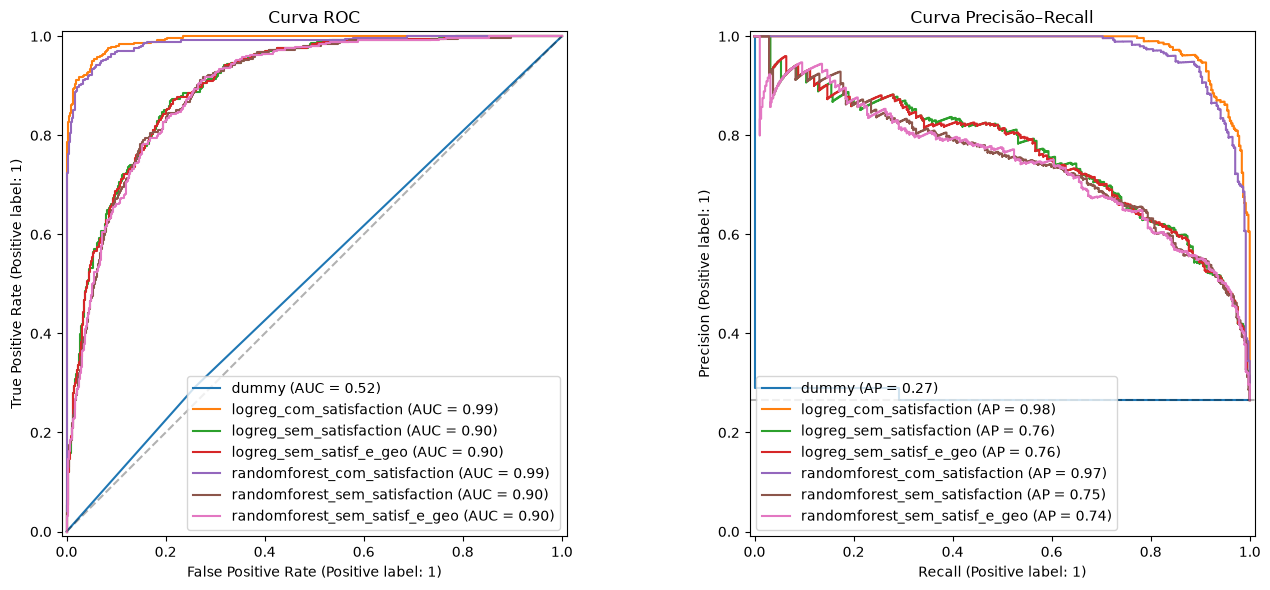

In [28]:
# Curvas que formam o ROC-AUC e o PR-AUC

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

for nome, (yt, yp) in predicoes.items():
    RocCurveDisplay.from_predictions(yt, yp, name=nome, ax=ax_roc)
    PrecisionRecallDisplay.from_predictions(yt, yp, name=nome, ax=ax_pr)

# Linhas de referência do modelo "sem skill"
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.3)                    # ROC: diagonal (aleatório)
ax_pr.axhline(y.mean(), color="k", linestyle="--", alpha=0.3)   # PR: prevalência do churn

ax_roc.set_title("Curva ROC")
ax_pr.set_title("Curva Precisão–Recall")

plt.tight_layout()
plt.show()


### Resumo dos baselines

O **DummyClassifier (stratified)** estabelece o piso de performance: PR-AUC de **0,272** (próximo à prevalência de churn de 26,5%), confirmando que qualquer modelo acima disso está aprendendo sinal real dos dados.

A **Regressão Logística** sem `SatisfactionScore` atinge PR-AUC de **0,764** — um lift substancial sobre o piso, obtido pela combinação de múltiplas features moderadas (nenhuma com correlação individual > 0,35). Não apresenta overfitting (diferença treino-teste de -0,010).

**Random Forest** sem `SatisfactionScore` atinge PR-AUC de **0,747** — novamente um lift substancial sobre o piso e sem apresentar overfitting (diferença treino-teste de -0,025).

Ao incluir `SatisfactionScore`, a PR-AUC salta para **0,980 e 0,972 (regrassão logística e random forest)** — um ganho desproporcional que confirma a suspeita levantada na EDA: a variável é **data leakage**. Esse score de satisfação é coletado após o evento de churn (ou é derivado dele), tornando-o indisponível no momento da predição em produção.

**Decisão: `SatisfactionScore` será excluída definitivamente do estudo.** O modelo honesto (sem ela) já demonstra capacidade preditiva forte, e mantê-la inflaria artificialmente as métricas sem refletir performance real em deploy.

## 7. Conclusões e próximos passos


**Conclusões**  
A EDA revelou um dataset de 7.043 clientes com 26,5% de churn (desbalanceamento moderado, ratio 0,36), sem bloqueios de qualidade. Das 50 colunas originais, 16 foram removidas por leakage, redundância, constância ou alta cardinalidade. SatisfactionScore, inicialmente classificada como leakage suspeito, foi confirmada como data leakage — a PR-AUC da Regressão Logística salta de 0,786 para 0,980 ao incluí-la, um ganho incompatível com uma feature legítima. Será excluída definitivamente.

O DummyClassifier (stratified) estabeleceu o piso em PR-AUC 0,272 (≈ prevalência). A Regressão Logística sem SatisfactionScore alcançou PR-AUC de 0,768 sem overfitting, demonstrando que o conjunto de features moderadas (nenhuma com correlação > 0,35) carrega sinal preditivo forte quando combinadas.

**Próximos passos**  
Treinar MLP em PyTorch e comparar com os baselines (≥ 4 métricas)
Testar class_weight="balanced" na Regressão Logística para avaliar trade-off de recall (atual: 0,666 — perde 1/3 dos churners)
Analisar trade-off de custo falso positivo × falso negativo
Versionar o dataset no MLflow
Refatorar pré-processamento para Pipeline/ColumnTransformer (Marco 3)
Elaborar ML Canvas e Model Card